In [1]:
import torch
from torch import nn, optim, distributions
import squidpy as sq
import scanpy as sc
from tqdm.autonotebook import tqdm
import matplotlib.pyplot as plt
import numpy as np

from gpzoo.kernels import batched_RBF
from gpzoo.utilities import add_jitter

/tmp/ipykernel_76229/4168005162.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
def build_KL(means, scales, L):

    means_shape = means.shape

    L_diags = torch.diag(L)

    log_L_diags = means_shape[-1]*2*torch.sum(torch.log(L_diags))

    log_scales_diag = 2*torch.sum(torch.log(scales))
    
                            
    vals = torch.linalg.solve_triangular(L, means, upper=False)
    vals = torch.sum(vals**2)

    
    
    diags = torch.diag_embed(scales.T)
    B = torch.linalg.solve_triangular(L, diags.view(means_shape[-1] * means_shape[0], -1).T, upper=False)
    trace_term = torch.sum(B**2)


    return log_L_diags - log_scales_diag + vals + trace_term
    

In [3]:
def plot_factors(factors, X, moran_idx=None, ax=None, size=7, alpha=0.8, s=0.1, names=None, max_val=None, min_val=None):

    if max_val is None:
        max_val = np.percentile(factors, 99)
        min_val = np.percentile(factors, 1)

    print(max_val)
    print(min_val)


    if moran_idx is not None:
        factors = factors[moran_idx]
        if names is not None:
            names = names[moran_idx]

    L = len(factors)

    if ax is None:
        fig, ax = plt.subplots(4, 5, figsize=(size*5, size*4), tight_layout=True)

    for i in range(L):


        curr_ax = ax[i//5, i%5]



        curr_ax.scatter(X[:, 0], X[:,1], c=factors[i], vmin=min_val, vmax=max_val, alpha=alpha, cmap='turbo', s=s)

        curr_ax.invert_yaxis()
        if names is not None:
            curr_ax.set_title(names[i], x=0.03, y=.88, fontsize="small", c="white",
                     ha="left", va="top")

        curr_ax.set_xticks([])
        curr_ax.set_yticks([])
        curr_ax.set_facecolor('xkcd:gray')

In [4]:
class Encoder(nn.Module):
  def __init__(self, L):
    super().__init__()
    self.W1 = nn.Linear(2, 1024)
    self.bn1 = nn.BatchNorm1d(1024)
    self.W2 = nn.Linear(1024, 1024)
    self.bn2 = nn.BatchNorm1d(1024)
    self.W3 = nn.Linear(1024, 512)
    self.bn3 = nn.BatchNorm1d(512)
    self.W4 = nn.Linear(512, 256)
    self.bn4 = nn.BatchNorm1d(256)
    self.W5 = nn.Linear(256, 128)
    self.bn5 = nn.BatchNorm1d(128)

    
    self.mean_net = nn.Linear(128, L)
    self.cov_net = nn.Linear(128, L)


  def forward(self, x):

    
    Z1 = nn.functional.relu(self.W1(x))
    Z1 = self.bn1(Z1)
    Z2 = nn.functional.relu(self.W2(Z1))
    Z2 = self.bn2(Z2)

    Z3 = nn.functional.softplus(self.W3(Z2))
    Z3 = self.bn3(Z3)

    Z4 = nn.functional.softplus(self.W4(Z3))
    Z4 = self.bn4(Z4)
      
    Z5 = nn.functional.softplus(self.W5(Z4))
    Z5 = self.bn5(Z5)

    mean = self.mean_net(Z5)
    scale = nn.functional.softplus(self.cov_net(Z5))
    return mean, scale

In [5]:
class Decoder(nn.Module):
  def __init__(self, L, D):
    super().__init__()

    self.W = nn.Parameter(torch.randn(L, D))

  def forward(self, Z):

    W = nn.functional.softplus(self.W)
    X = Z@W

    return X

In [6]:
class BigModel(nn.Module):
  def __init__(self, X, Y, L, kernel):
    super().__init__()

    N, d = X.shape
    N, D = Y.shape

    self.encoder = Encoder(L=L)
    self.decoder = Decoder(L=L, D=D)
    self.kernel = kernel

  def forward(self, X, E=3):

    mean, scale = self.encoder(X)

    Kxx = kernel(X, X).contiguous().detach()
    L = torch.cholesky(add_jitter(Kxx, 1e-4))
    
    qF = distributions.Normal(mean, torch.clamp(scale, min=1e-4))
    

    F = qF.rsample((E, ))

    F = nn.functional.softplus(F)
    
    X_reconstructed = self.decoder(F)

    return X_reconstructed, qF, L

In [7]:
adata = sq.datasets.slideseqv2()
adata = adata.raw.to_adata()

<Axes: >

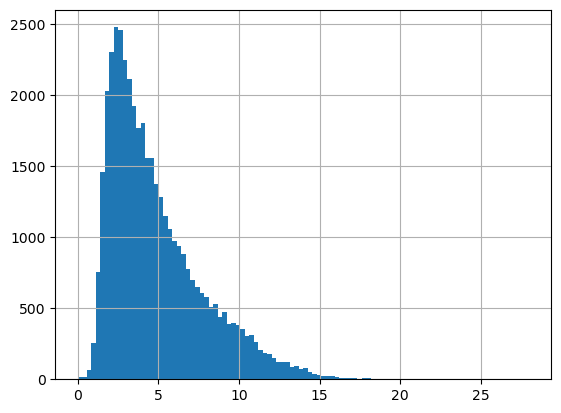

In [8]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
adata.obs.pct_counts_mt.hist(bins=100)

In [9]:
X = adata.obsm["spatial"].copy()
Y = adata.X.toarray()
X = torch.tensor(X).type(torch.float)/1000
Y = torch.tensor(Y).type(torch.float)
Y = Y[:,~adata.var.MT]

/tmp/ipykernel_76229/2225379389.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Y = Y[:,~adata.var.MT]


In [10]:
kernel = batched_RBF()
model = BigModel(X, Y, L=20, kernel=kernel)

In [11]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

In [12]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [13]:
def train_batched(model, optimizer, X, y, device, steps=200, batch_size=1000, E=3, **kwargs):
    losses = []

    for it in tqdm(range(steps)):

        idx = torch.multinomial(torch.ones(X.shape[0]), num_samples=batch_size, replacement=False)

        
        optimizer.zero_grad()
        Y_reconstructed, qF, L = model(X[idx], E=E)

        logpY = y[idx]*torch.log(torch.clamp(Y_reconstructed,1e-4)) - Y_reconstructed
        ELBO = (logpY).mean(axis=0).sum()
        ELBO -= build_KL(qF.mean, qF.scale, L)
        loss = -ELBO

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    with torch.no_grad():
        if device.type=='cuda':
            torch.cuda.empty_cache()

    return losses

In [14]:
X_train = X.to(device)
Y_train = Y.to(device)

In [ ]:
model.to(device)
model.train()
losses = train_batched(model, optimizer, X_train, Y_train, device, steps=6*10000, batch_size=4000, E=3)

  0%|          | 0/60000 [00:00<?, ?it/s]

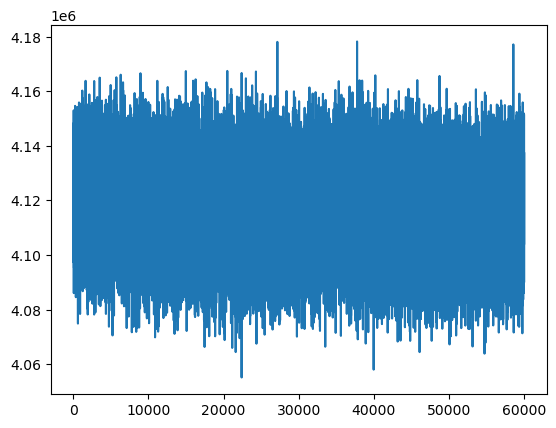

In [52]:
plt.plot(losses)

In [46]:
model.to('cpu')

BigModel(
  (encoder): Encoder(
    (W1): Linear(in_features=2, out_features=1024, bias=True)
    (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (W2): Linear(in_features=1024, out_features=1024, bias=True)
    (bn2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (W3): Linear(in_features=1024, out_features=512, bias=True)
    (bn3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (W4): Linear(in_features=512, out_features=256, bias=True)
    (bn4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (W5): Linear(in_features=256, out_features=128, bias=True)
    (bn5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (mean_net): Linear(in_features=128, out_features=20, bias=True)
    (cov_net): Linear(in_features=128, out_features=20, bias=True)
  )
  (decoder): Decoder()
  (kernel): batched_RBF()
)

In [47]:
model.eval()

BigModel(
  (encoder): Encoder(
    (W1): Linear(in_features=2, out_features=1024, bias=True)
    (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (W2): Linear(in_features=1024, out_features=1024, bias=True)
    (bn2): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (W3): Linear(in_features=1024, out_features=512, bias=True)
    (bn3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (W4): Linear(in_features=512, out_features=256, bias=True)
    (bn4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (W5): Linear(in_features=256, out_features=128, bias=True)
    (bn5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (mean_net): Linear(in_features=128, out_features=20, bias=True)
    (cov_net): Linear(in_features=128, out_features=20, bias=True)
  )
  (decoder): Decoder()
  (kernel): batched_RBF()
)

In [48]:
X_test = torch.cartesian_prod(torch.linspace(-2, 7, 200), torch.linspace(-2, 7, 200))

In [49]:
mean, scale = model.encoder(X)

F =nn.functional.softplus(mean).detach().cpu().numpy()
scale = scale.detach().cpu().numpy()

0.03237421888858079
2.3435525147164073e-08


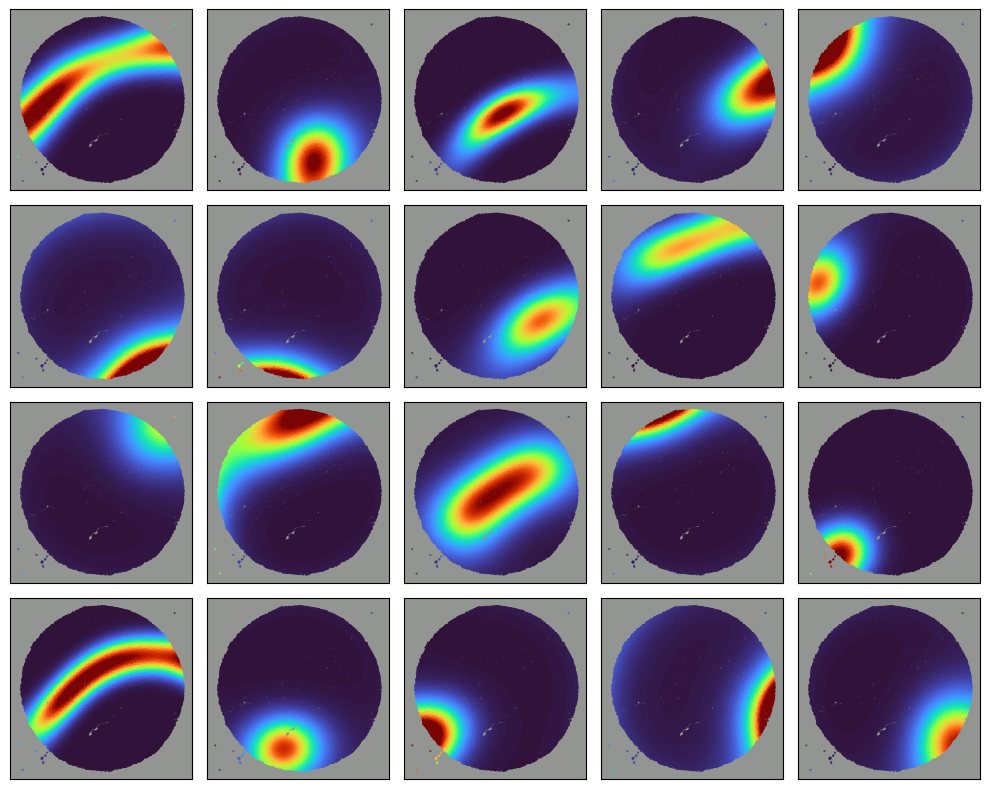

In [50]:
plot_factors(F.T, X, moran_idx=None, ax=None, size=2, s=0.2, alpha=0.9)

In [51]:
F.max()

0.07714904